In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
T = 100
V_TH = 2
V_RESET = 0
TAU = 0.8

I = jnp.zeros(T)
I = I.at[10:40].set(0.6)
I = I.at[60:90].set(1.2)

print(I)

[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6 0.6 0.6 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2
 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]


In [3]:
class IFneuron:
    def __init__(self, V_th: int, V_reset: int | None = None):
        self.V_t = 0
        self.V_th = V_th
        self.V_reset = V_reset

    def update(self, i:int):
        self.V_t = self.V_t + i
        spike = 1 if self.V_t >= self.V_th else 0

        if spike:
            self.reset()

        return spike, self.V_t

    def reset(self):
        if self.V_reset is not None:
            self.V_t = self.V_reset
        else:
            self.V_t = self.V_t - self.V_th

In [4]:
output_python_spikes = []
output_python_voltages = []
if_neuron = IFneuron(V_th=V_TH, V_reset=V_RESET)
for t in range(T):
    output_spike, output_voltage = if_neuron.update(I[t])
    output_python_spikes.append(output_spike)
    output_python_voltages.append(output_voltage)
print(output_python_spikes)
print(output_python_voltages)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0.6, dtype=float32), Array(1.2, dtype=float32), Array(1.8000001, dtype=float32), 0, Array(0.6, dtype=float32), Array(1.2, dtype=float32), Array(1.8000001, dtype=float32), 0, Array(0.6, dtype=float32), Array(1.2, dtype=float32), Array(1.8000001, dtype=float32), 0, Array(0.6, dtype=float32), Array(1.2, dtype=float32), Array(1.8000001, dtype=float32), 0, Array(0.6, dtype=float32), Array(1.2, dtype=float32), Array(1.8000001, dtype=f

In [5]:
def if_step(v, I_t, V_th, V_reset):
    v = v + I_t
    spike = (v >= V_th).astype(jnp.float32)
    v = jnp.where(spike, V_reset, v)

    return v, spike

In [6]:
def scan_fn(carry, input):
    new_v, spike = if_step(carry, input, V_th=V_TH, V_reset=V_RESET)
    return new_v, (spike,new_v)
carry, (outputs_jax_spikes, output_jax_voltages) = jax.lax.scan(scan_fn, 0.0, I)
print(outputs_jax_spikes)
print(output_jax_voltages)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.
 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.6       1.2       1.8000001 0.
 0.6       1.2       1.8000001 0.        0.6       1.2       1.8000001
 0.        0.6       1.2       1.8000001 0.        0.6       1.2
 1.8000001 0.        0.6       1.2       1.8000001 0.        0.6
 1.2       1.8000001 0.        0.6       1.2       1.2       1.2
 1.2       1.2       1.2       1.2       1.2       1.2       1.2
 1.2       1.2       1.2       1.2       1.2       1.2       1.2
 1.2       1.2       1.2       1.2       0.        1.2       0.
 1.2       0.        1.2       0.        1.2       0.        1.2
 0.        1.2       0.        1.2       

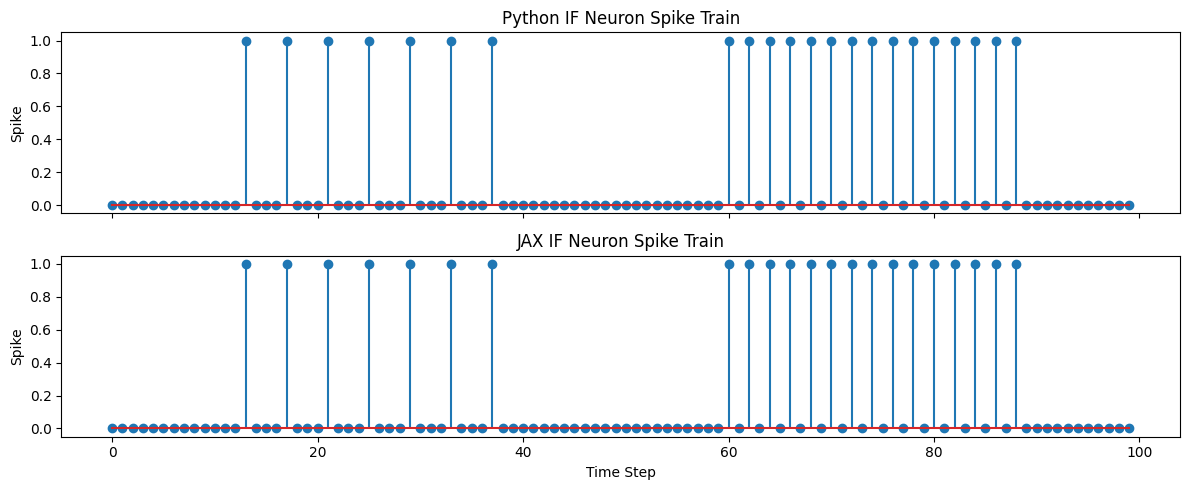

In [7]:
time = np.arange(T)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# Python spike train
ax[0].stem(time, output_python_spikes)
ax[0].set_title("Python IF Neuron Spike Train")
ax[0].set_ylabel("Spike")

# JAX spike train
ax[1].stem(time, np.array(outputs_jax_spikes))
ax[1].set_title("JAX IF Neuron Spike Train")
ax[1].set_ylabel("Spike")
ax[1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()

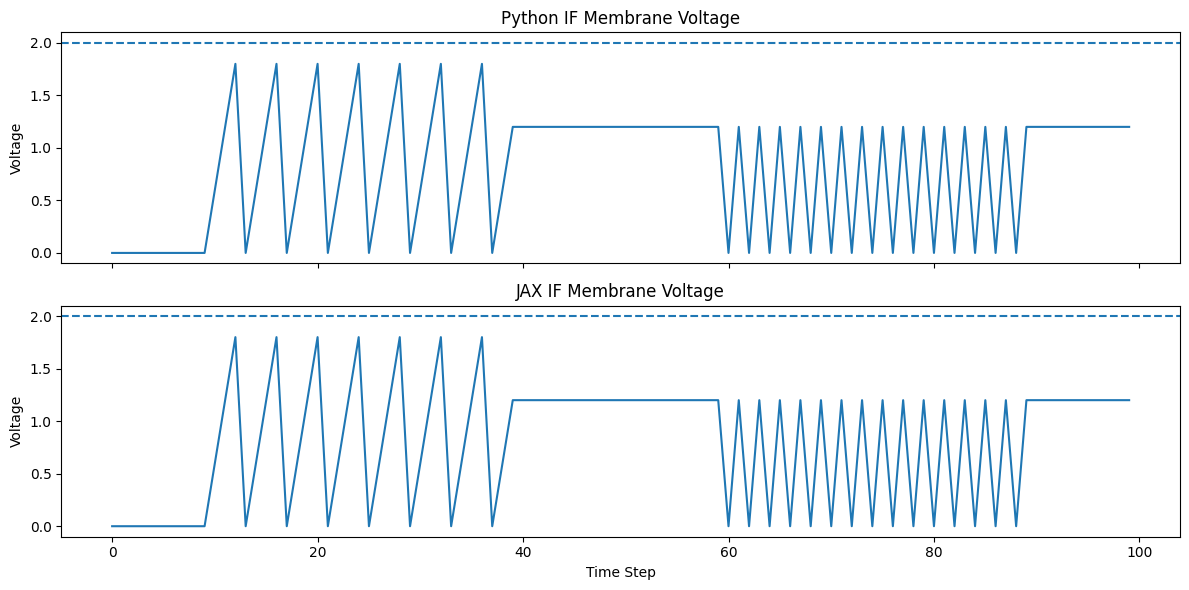

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Python membrane voltage
ax[0].plot(time, output_python_voltages)
ax[0].axhline(2.0, linestyle="--")
ax[0].set_title("Python IF Membrane Voltage")
ax[0].set_ylabel("Voltage")

# JAX membrane voltage
ax[1].plot(time, np.array(output_jax_voltages))
ax[1].axhline(2.0, linestyle="--")
ax[1].set_title("JAX IF Membrane Voltage")
ax[1].set_ylabel("Voltage")
ax[1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()

In [9]:
class LIFneuron:
    def __init__(self, V_th: int, tau:int, V_reset: int | None = None):
        self.V_t = 0
        self.V_th = V_th
        self.V_reset = V_reset
        self.tau = tau

    def update(self, i:int):
        self.V_t = self.tau * self.V_t + i
        spike = 1 if self.V_t >= self.V_th else 0

        if spike:
            self.reset()

        return spike, self.V_t

    def reset(self):
        if self.V_reset is not None:
            self.V_t = self.V_reset
        else:
            self.V_t = self.V_t - self.V_th

In [10]:
output_python_spikes = []
output_python_voltages = []
if_neuron = LIFneuron(V_th=V_TH, tau = TAU,V_reset=V_RESET)
for t in range(T):
    output_spike, output_voltage = if_neuron.update(I[t])
    output_python_spikes.append(output_spike)
    output_python_voltages.append(output_voltage)
print(output_python_spikes)
print(output_python_voltages)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0., dtype=float32), Array(0.6, dtype=float32), Array(1.08, dtype=float32), Array(1.464, dtype=float32), Array(1.7712001, dtype=float32), 0, Array(0.6, dtype=float32), Array(1.08, dtype=float32), Array(1.464, dtype=float32), Array(1.7712001, dtype=float32), 0, Array(0.6, dtype=float32), Array(1.08, dtype=float32), Array(1.464, dtype=float32), Array(1.7712001, dtype=float32), 0, Array(0.6, dtype=float32), Array(1.08, dtype=float32), Array(1.464, dtype=floa

In [11]:
def lif_step(v, I_t, V_th, tau, V_reset):
    v = tau * v + I_t
    spike = (v >= V_th).astype(jnp.float32)
    v = jnp.where(spike, V_reset, v)

    return v, spike

In [12]:
def scan_fn(carry, input):
    new_v, spike = lif_step(carry, input, V_th=V_TH, tau=TAU, V_reset=V_RESET)
    return new_v, (spike,new_v)
carry, (outputs_jax_spikes, output_jax_voltages) = jax.lax.scan(scan_fn, 0.0, I)
print(outputs_jax_spikes)
print(output_jax_voltages)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.6       1.08      1.4640001 1.7712002
 0.        0.6       1.08      1.4640001 1.7712002 0.        0.6
 1.08      1.4640001 1.7712002 0.        0.6       1.08      1.4640001
 1.7712002 0.        0.6       1.08      1.4640001 1.7712002 0.
 0.6       1.08      1.4640001 1.7712002 0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        1.2       0.        1.2
 0.        1.2       0.        1.2       0.        1.2       0.
 1.2       0.        1.2       0.     

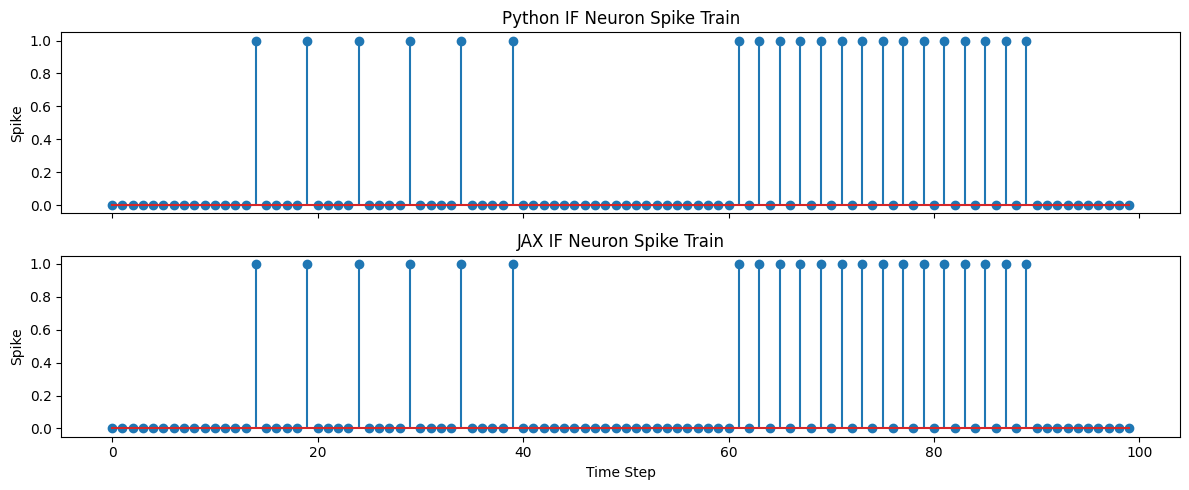

In [13]:
time = np.arange(T)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# Python spike train
ax[0].stem(time, output_python_spikes)
ax[0].set_title("Python IF Neuron Spike Train")
ax[0].set_ylabel("Spike")

# JAX spike train
ax[1].stem(time, np.array(outputs_jax_spikes))
ax[1].set_title("JAX IF Neuron Spike Train")
ax[1].set_ylabel("Spike")
ax[1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()

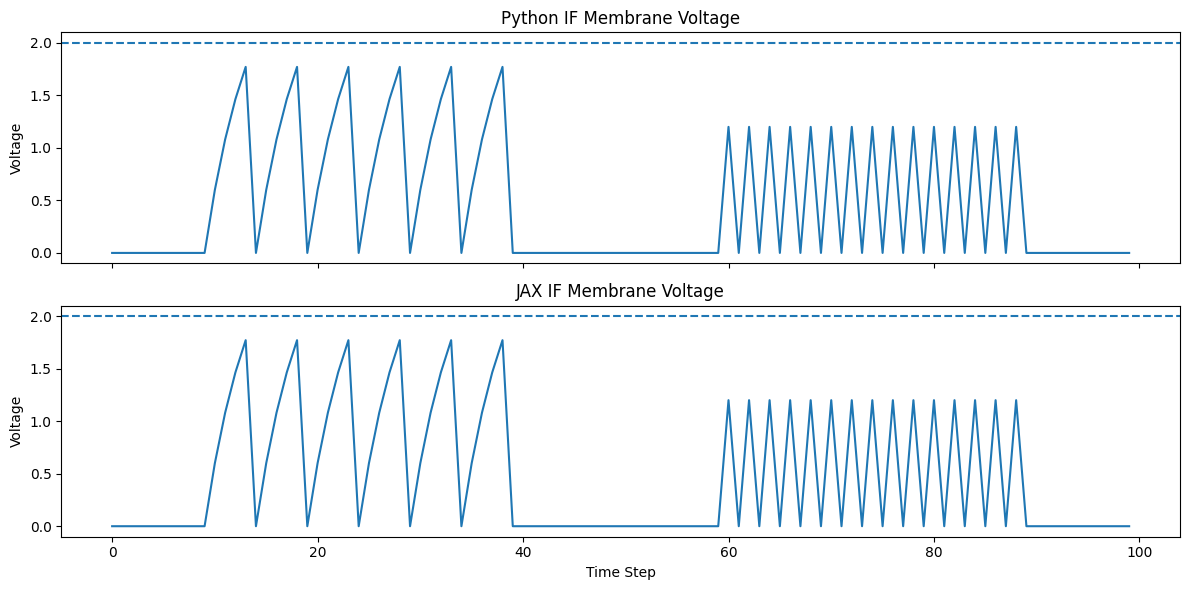

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Python membrane voltage
ax[0].plot(time, output_python_voltages)
ax[0].axhline(2.0, linestyle="--")
ax[0].set_title("Python IF Membrane Voltage")
ax[0].set_ylabel("Voltage")

# JAX membrane voltage
ax[1].plot(time, np.array(output_jax_voltages))
ax[1].axhline(2.0, linestyle="--")
ax[1].set_title("JAX IF Membrane Voltage")
ax[1].set_ylabel("Voltage")
ax[1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()